# Validation Results
Inspect mean/median distance metrics and proximity percentages.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import pandas as pd

ROOT = Path('..').resolve()
metrics_path = ROOT / 'experiments/metrics.json'
run_validation_script = ROOT / 'scripts' / 'run_validation.py'
metrics_path

WindowsPath('C:/Users/karth/PrediCT/experiments/metrics.json')

In [2]:
needs_validation = (not metrics_path.exists()) or (metrics_path.stat().st_size == 0)
if needs_validation:
    print('metrics.json missing or empty. Running validation script...')
    subprocess.run([sys.executable, str(run_validation_script)], cwd=str(ROOT), check=True)

if metrics_path.exists() and metrics_path.stat().st_size > 0:
    metrics = json.loads(metrics_path.read_text())
    display(pd.DataFrame([metrics]))
else:
    raise FileNotFoundError('metrics.json could not be generated. Run scripts/run_validation.py manually.')

,scan_id,threshold_mm,mean_distance_mm,median_distance_mm,percent_within_10mm,plots,runtime_seconds,registration_strategy
0,sample_calcium_mask.nii,10.0,5.038787,2.44949,79.321663,{'ct_calcium_overlay': 'C:\Users\karth\PrediCT...,1.2359,affine


In [3]:
key_cols = ['mean_distance_mm', 'median_distance_mm', 'percent_within_10mm']
for c in key_cols:
    print(f'{c}:', metrics.get(c, 'n/a'))

mean_distance_mm: 5.038787364959717
median_distance_mm: 2.4494898319244385
percent_within_10mm: 79.32166301969366


## Multi-Scan Synthetic Validation
Run synthetic validation across seeds 42-61 (20 scans), compute proximity metrics directly from package modules, save per-scan results to `experiments/multi_scan_validation.csv`, and summarize stability.

In [4]:
import sys
from pathlib import Path
from typing import cast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from predict_cac.utils.synthetic_data import generate_synthetic_demo_data
from predict_cac.evaluation.proximity_metrics import calcium_distance_summary

import nibabel as nib

In [5]:
rows = []
for seed in range(42, 62):
    _ = generate_synthetic_demo_data(ROOT, seed=seed)

    calcium_path = ROOT / 'data/masks/sample_calcium_mask.nii.gz'
    centerline_path = ROOT / 'outputs/centerlines_warped/sample_centerline_mask.nii.gz'

    cal_img = cast(nib.Nifti1Image, nib.load(str(calcium_path)))
    ctr_img = cast(nib.Nifti1Image, nib.load(str(centerline_path)))

    calcium = np.asarray(cal_img.get_fdata(), dtype=np.float32)
    centerline = np.asarray(ctr_img.get_fdata(), dtype=np.float32)
    raw_zooms = [float(v) for v in cal_img.header.get_zooms()]
    while len(raw_zooms) < 3:
        raw_zooms.append(1.0)
    spacing_xyz = (raw_zooms[0], raw_zooms[1], raw_zooms[2])

    stats = calcium_distance_summary(
        calcium_mask=calcium,
        centerline_mask=centerline,
        spacing_xyz=spacing_xyz,
        threshold_mm=10.0,
    )

    rows.append(
        {
            'seed': seed,
            'mean_distance_mm': stats['mean_distance_mm'],
            'median_distance_mm': stats['median_distance_mm'],
            'percent_within_10mm': stats['percent_within_10mm'],
        }
    )

multi_scan_df = pd.DataFrame(rows)
multi_scan_df.head()

,seed,mean_distance_mm,median_distance_mm,percent_within_10mm
0,42,5.038787,2.449490,79.321663
1,43,5.638251,3.316625,74.495413
2,44,4.870050,2.828427,78.224299
3,45,4.288672,3.000000,88.876404
4,46,6.048715,3.000000,68.331442


In [6]:
out_csv = ROOT / 'experiments/multi_scan_validation.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
multi_scan_df.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')

summary_df = pd.DataFrame(
    {
        'metric': ['percent_within_10mm'],
        'mean': [multi_scan_df['percent_within_10mm'].mean()],
        'median': [multi_scan_df['percent_within_10mm'].median()],
        'std': [multi_scan_df['percent_within_10mm'].std()],
    }
)
summary_df

Saved: C:\Users\karth\PrediCT\experiments\multi_scan_validation.csv


,metric,mean,median,std
0,percent_within_10mm,79.32782,78.824011,7.700457


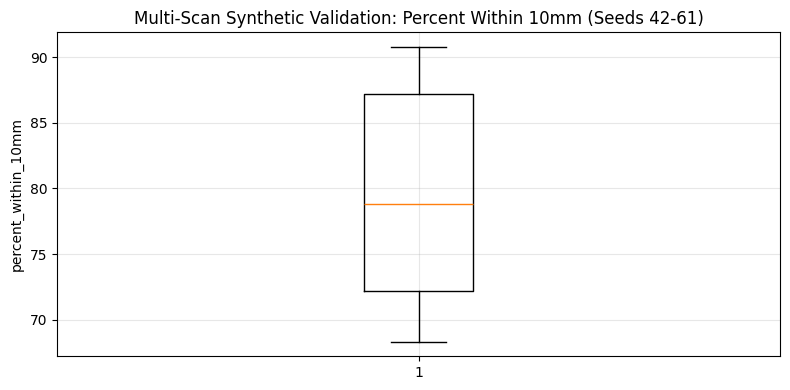

In [7]:
plt.figure(figsize=(8, 4))
plt.boxplot(multi_scan_df['percent_within_10mm'])
plt.ylabel('percent_within_10mm')
plt.title('Multi-Scan Synthetic Validation: Percent Within 10mm (Seeds 42-61)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()